# Netflix Catalog — Exploratory Data Analysis (2011–2020)

Notebook này trả lời 5 câu hỏi EDA cốt lõi của dự án bằng dữ liệu đã chuẩn hóa.

**Phạm vi:** ngày nội dung được thêm vào Netflix từ 01/01/2011 đến 31/12/2020.  
**Grain chính:** một dòng trong `dim_title` tương ứng một title Netflix.  
**Nguyên tắc:** sử dụng `COUNT DISTINCT show_id`; các tỷ lệ theo genre/country không cộng thành 100% vì một title có thể thuộc nhiều genre hoặc country.

Mỗi phần tuân theo cấu trúc: **Question → Metric → Chart → Observation → Caveat**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "figure.dpi": 120,
})

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "data" / "normalized").exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / "data" / "normalized"

titles = pd.read_csv(DATA_DIR / "dim_title.csv", parse_dates=["date_added"])
genres = pd.read_csv(DATA_DIR / "bridge_genre.csv")
countries = pd.read_csv(DATA_DIR / "bridge_country.csv")
monthly = pd.read_csv(DATA_DIR / "fact_monthly_addition.csv", dtype={"date_key": "string"})

titles["added_year"] = titles["date_added"].dt.year
monthly["month"] = pd.to_datetime(monthly["date_key"], format="%Y%m%d")

print(f"Loaded {len(titles):,} titles, {len(genres):,} title–genre rows, "
      f"{len(countries):,} title–country rows, and {len(monthly):,} months.")

Loaded 7,294 titles, 16,026 title–genre rows, 8,528 title–country rows, and 120 months.


## 1. Kiểm tra dữ liệu đầu vào

Các assertion dưới đây bảo đảm grain, phạm vi thời gian và tổng additions nhất quán trước khi phân tích.

In [2]:
assert titles["show_id"].is_unique, "dim_title phải có một dòng cho mỗi show_id"
assert titles["date_added"].notna().all(), "date_added không được null trong tập phân tích"
assert titles["date_added"].between("2011-01-01", "2020-12-31").all()
assert not genres.duplicated(["show_id", "genre"]).any()
assert not countries.duplicated(["show_id", "country"]).any()
assert monthly["monthly_additions"].sum() == titles["show_id"].nunique()
assert monthly["month_index"].tolist() == list(range(120))

quality_summary = pd.DataFrame({
    "Kiểm tra": [
        "Số title duy nhất",
        "Tổng monthly additions",
        "Số tháng liên tục",
        "Title có rating",
        "Title có country",
        "Title có genre",
    ],
    "Kết quả": [
        titles["show_id"].nunique(),
        int(monthly["monthly_additions"].sum()),
        len(monthly),
        titles.loc[titles["rating"].notna(), "show_id"].nunique(),
        countries["show_id"].nunique(),
        genres["show_id"].nunique(),
    ],
})
display(quality_summary)
print("PASS — dữ liệu sẵn sàng cho EDA.")

,Kiểm tra,Kết quả
0,Số title duy nhất,7294
1,Tổng monthly additions,7294
2,Số tháng liên tục,120
3,Title có rating,7290
4,Title có country,6822
5,Title có genre,7294


PASS — dữ liệu sẵn sàng cho EDA.


## 2. Tổng quan metric

- **Total titles:** `COUNT DISTINCT dim_title.show_id`.
- **Movie/TV Show share:** số title theo type / tổng title.
- **Annual additions:** số title duy nhất theo năm của `date_added`.
- **Genre/Country title count:** số `show_id` duy nhất theo giá trị trong bảng bridge.
- **Rating share:** số title theo rating / số title có rating.

In [3]:
type_counts = titles.groupby("type")["show_id"].nunique().sort_values(ascending=False)
overview = pd.Series({
    "Total titles": titles["show_id"].nunique(),
    "Movies": type_counts.get("Movie", 0),
    "TV Shows": type_counts.get("TV Show", 0),
    "Movie share (%)": round(type_counts.get("Movie", 0) / len(titles) * 100, 1),
    "TV Show share (%)": round(type_counts.get("TV Show", 0) / len(titles) * 100, 1),
    "Country coverage (%)": round(countries["show_id"].nunique() / len(titles) * 100, 1),
    "Rating coverage (%)": round(titles["rating"].notna().mean() * 100, 1),
}, name="Value")
display(overview.to_frame())

,Value
Total titles,7294.0
Movies,5134.0
TV Shows,2160.0
Movie share (%),70.4
TV Show share (%),29.6
Country coverage (%),93.5
Rating coverage (%),99.9


## Chart 1 — Số title được thêm theo năm

**Question:** Số title được thêm vào Netflix thay đổi như thế nào trong 2011–2020?  
**Metric:** `COUNT DISTINCT show_id` theo năm của `date_added`.  
**Chart:** Line chart có nhãn giá trị.

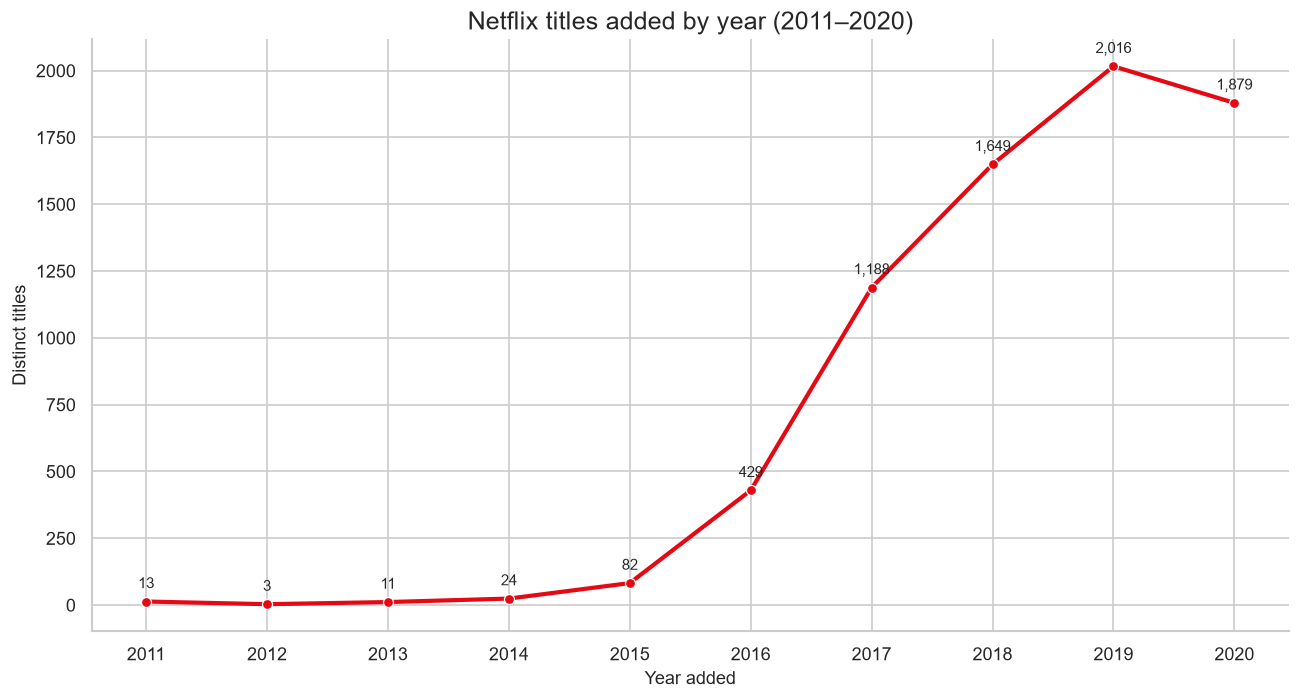

Peak: 2019 with 2,016 titles.
2020 vs 2019: -6.8%.


In [4]:
annual = titles.groupby("added_year")["show_id"].nunique().reindex(range(2011, 2021), fill_value=0)

fig, ax = plt.subplots()
sns.lineplot(x=annual.index, y=annual.values, marker="o", linewidth=2.5, color="#E50914", ax=ax)
for year, value in annual.items():
    ax.annotate(f"{value:,}", (year, value), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax.set(title="Netflix titles added by year (2011–2020)", xlabel="Year added", ylabel="Distinct titles")
ax.set_xticks(annual.index)
sns.despine()
plt.tight_layout()
plt.show()

peak_year = int(annual.idxmax())
peak_value = int(annual.max())
change_2020 = (annual.loc[2020] / annual.loc[2019] - 1) * 100
print(f"Peak: {peak_year} with {peak_value:,} titles.")
print(f"2020 vs 2019: {change_2020:.1f}%.")

**Observation:** additions tăng nhanh từ 2016 và đạt đỉnh **2.016 title năm 2019**; năm 2020 còn **1.879 title**, giảm **6,8%** so với 2019.  
**Caveat:** đây là thời điểm title được thêm vào catalog, không phải năm phát hành hay mức độ phổ biến. Dataset là snapshot nên có thể không phản ánh đầy đủ lịch sử gỡ nội dung.

## Chart 2 — Cơ cấu và đóng góp của Movie và TV Show theo năm

**Question:** Movie và TV Show chiếm tỷ trọng như thế nào, và nhóm nào đóng góp nhiều hơn vào xu hướng tăng/giảm?  
**Metric:** `COUNT DISTINCT show_id` theo `added_year × type`, thể hiện cả số lượng tuyệt đối và tỷ lệ trong từng năm.  
**Chart:** 100% stacked bar chart và stacked bar chart theo số lượng tuyệt đối.

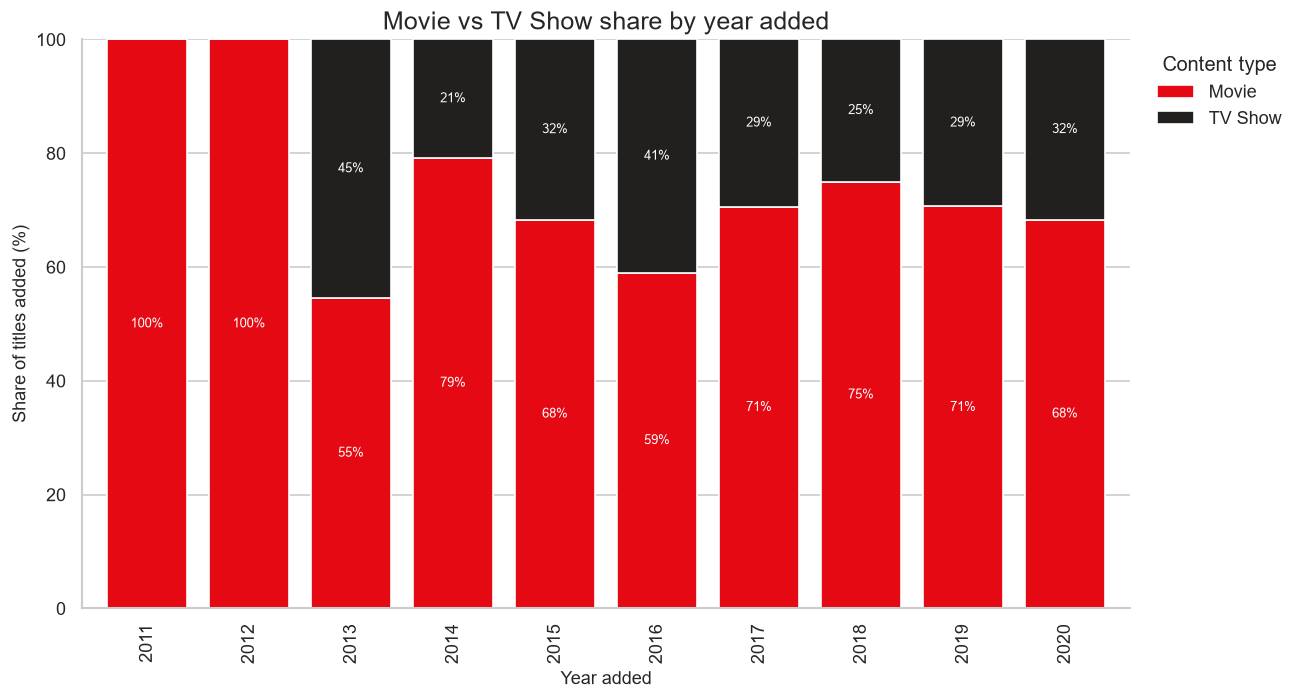

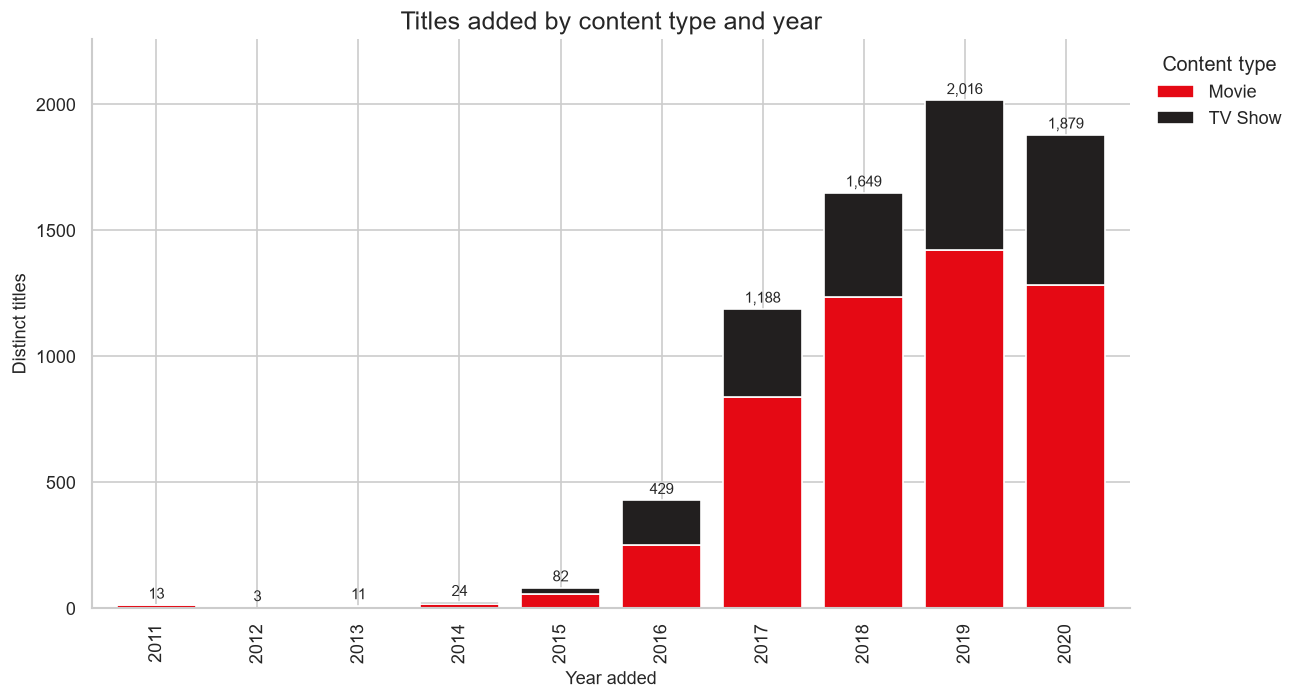

Đóng góp vào mức tăng 2016–2019:


,Số title tăng
type,
Movie,1171
TV Show,416


Thay đổi từ 2019 sang 2020:


,Số title thay đổi
type,
Movie,-140
TV Show,3


,titles,share_pct
type,,
Movie,5134,70.4
TV Show,2160,29.6


In [5]:
type_by_year = pd.crosstab(titles["added_year"], titles["type"]).reindex(range(2011, 2021), fill_value=0)
type_by_year = type_by_year.reindex(columns=["Movie", "TV Show"], fill_value=0)
type_share = type_by_year.div(type_by_year.sum(axis=1), axis=0).mul(100)

ax = type_share.plot(
    kind="bar", stacked=True, color=["#E50914", "#221F1F"], width=0.78, figsize=(11, 6)
)
ax.set(title="Movie vs TV Show share by year added", xlabel="Year added", ylabel="Share of titles added (%)")
ax.legend(title="Content type", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_ylim(0, 100)
for container in ax.containers:
    labels = [f"{v:.0f}%" if v >= 7 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", color="white", fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

ax = type_by_year.plot(
    kind="bar", stacked=True, color=["#E50914", "#221F1F"], width=0.78, figsize=(11, 6)
)
year_totals = type_by_year.sum(axis=1)
for position, total in enumerate(year_totals):
    ax.text(position, total + 25, f"{total:,}", ha="center", fontsize=9)
ax.set(title="Titles added by content type and year", xlabel="Year added", ylabel="Distinct titles")
ax.legend(title="Content type", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_ylim(0, year_totals.max() * 1.12)
sns.despine()
plt.tight_layout()
plt.show()

growth_2016_2019 = type_by_year.loc[2019] - type_by_year.loc[2016]
change_2019_2020 = type_by_year.loc[2020] - type_by_year.loc[2019]
print("Đóng góp vào mức tăng 2016–2019:")
display(growth_2016_2019.rename("Số title tăng").to_frame())
print("Thay đổi từ 2019 sang 2020:")
display(change_2019_2020.rename("Số title thay đổi").to_frame())

display(type_counts.rename("titles").to_frame().assign(share_pct=lambda x: (x["titles"] / len(titles) * 100).round(1)))

**Observation:** toàn giai đoạn có **5.134 Movie (70,4%)** và **2.160 TV Show (29,6%)**. Từ 2016 đến 2019, tổng additions tăng thêm 1.587 title; Movie đóng góp 1.171 title (73,8%) và TV Show đóng góp 416 title (26,2%). Năm 2020 giảm 137 title so với 2019: Movie giảm 140, còn TV Show tăng nhẹ 3 title. Vì vậy, mức giảm quan sát được trong năm 2020 chủ yếu đến từ Movie.  
**Caveat:** đây là phân rã đóng góp trong dataset, không chứng minh nguyên nhân kinh doanh. Các năm đầu có ít title nên tỷ lệ biến động mạnh; kết quả không đại diện cho lượt xem hay nhu cầu người dùng.

## Chart 3 — Top genre

**Question:** Những genre nào xuất hiện trên nhiều title nhất?  
**Metric:** `COUNT DISTINCT show_id` theo `bridge_genre.genre`.  
**Chart:** Horizontal bar chart cho top 10 genre.

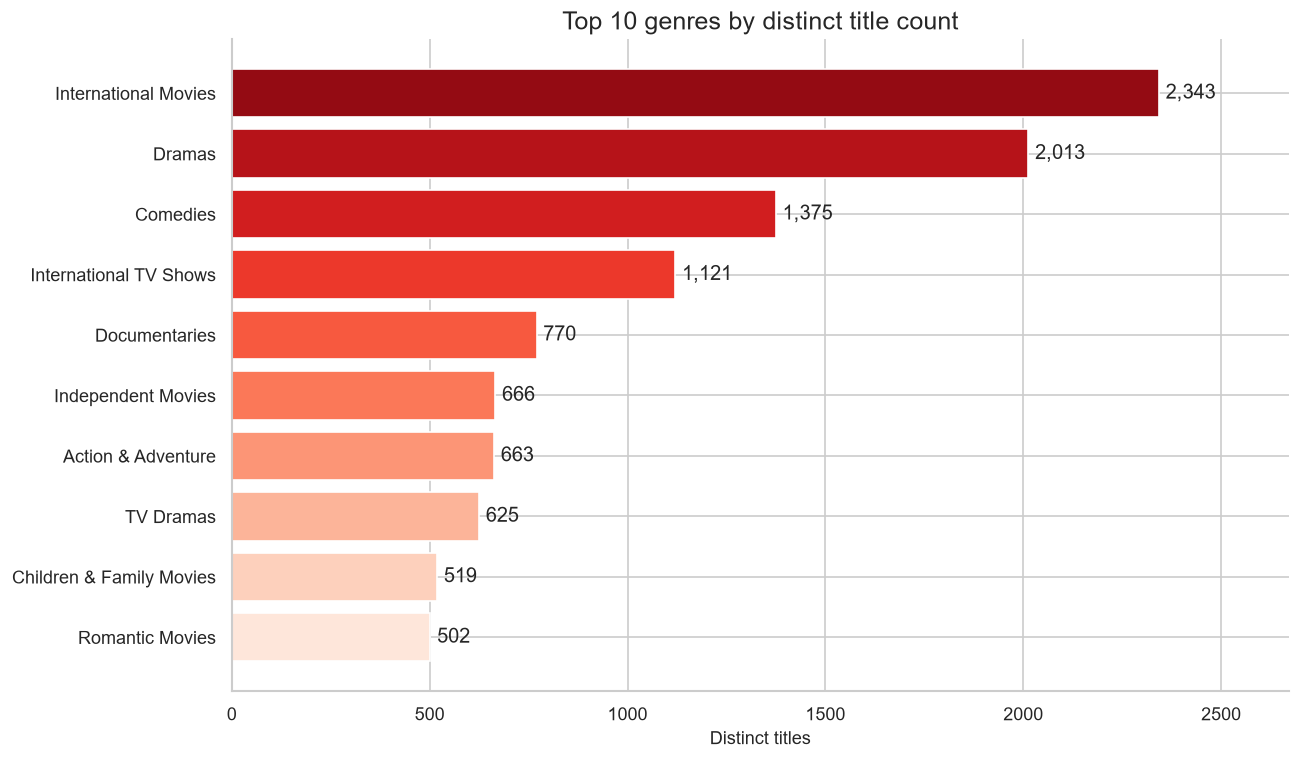

Top genre: International Movies — 2,343 titles (32.1% of all titles).


In [6]:
genre_counts = (
    genres.groupby("genre")["show_id"].nunique().sort_values(ascending=False).head(10).sort_values()
)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(genre_counts.index, genre_counts.values, color=sns.color_palette("Reds", len(genre_counts)))
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in genre_counts.values], padding=4)
ax.set(title="Top 10 genres by distinct title count", xlabel="Distinct titles", ylabel="")
ax.set_xlim(0, genre_counts.max() * 1.14)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Top genre: {genre_counts.index[-1]} — {genre_counts.iloc[-1]:,} titles "
      f"({genre_counts.iloc[-1] / len(titles) * 100:.1f}% of all titles).")

**Observation:** **International Movies** đứng đầu với **2.343 title (32,1%)**, tiếp theo là **Dramas (2.013)** và **Comedies (1.375)**.  
**Caveat:** genre là quan hệ nhiều-nhiều; một title có thể được đếm ở nhiều genre, vì vậy tổng các cột không bằng tổng số title và tỷ lệ không cộng thành 100%.

## Chart 4 — Top country

**Question:** Những quốc gia nào có nhiều title liên quan nhất?  
**Metric:** `COUNT DISTINCT show_id` theo `bridge_country.country`.  
**Chart:** Horizontal bar chart cho top 10 country.

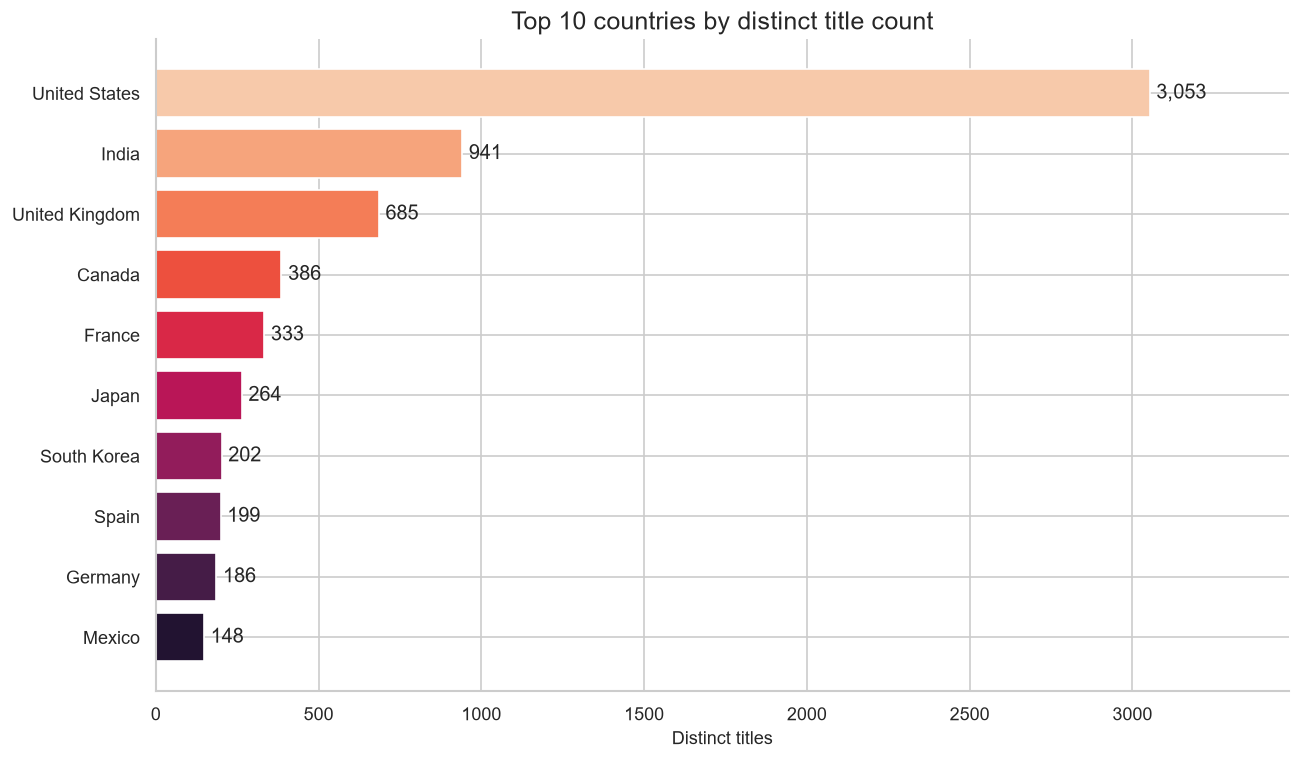

Country coverage: 93.5% (472 titles have no country row).


In [7]:
country_counts = (
    countries.groupby("country")["show_id"].nunique().sort_values(ascending=False).head(10).sort_values()
)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(country_counts.index, country_counts.values, color=sns.color_palette("rocket", len(country_counts)))
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in country_counts.values], padding=4)
ax.set(title="Top 10 countries by distinct title count", xlabel="Distinct titles", ylabel="")
ax.set_xlim(0, country_counts.max() * 1.14)
sns.despine()
plt.tight_layout()
plt.show()

country_coverage = countries["show_id"].nunique() / len(titles) * 100
missing_country = len(titles) - countries["show_id"].nunique()
print(f"Country coverage: {country_coverage:.1f}% ({missing_country:,} titles have no country row).")

**Observation:** **United States** liên quan đến **3.053 title**, tương đương **41,9%** tổng title; India (941) và United Kingdom (685) đứng tiếp theo.  
**Caveat:** country cũng là quan hệ nhiều-nhiều và chỉ thể hiện quốc gia được gắn với title. Có **472 title (6,5%)** không có country, nên không suy diễn thành thị phần sản xuất tuyệt đối.

## Chart 5 — Rating heatmap

**Question:** Cơ cấu rating độ tuổi thay đổi như thế nào theo năm thêm vào?  
**Metric:** tỷ lệ title có rating trong từng năm, theo 8 rating phổ biến nhất toàn giai đoạn.  
**Chart:** Heatmap tỷ lệ phần trăm (`added_year × rating`).

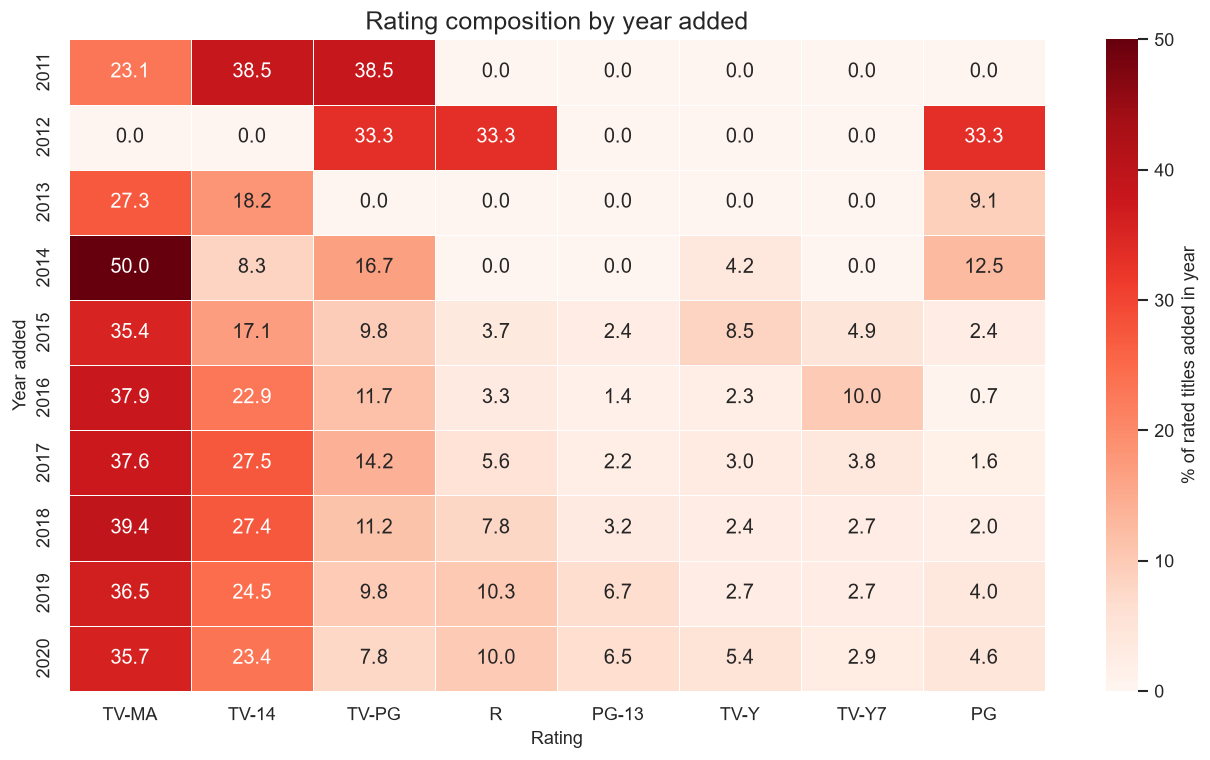

TV-MA + TV-14: 4,543/7,290 rated titles (62.3%).
Missing rating: 4 titles.


In [8]:
top_ratings = titles["rating"].value_counts().head(8).index
rating_share = pd.crosstab(titles["added_year"], titles["rating"], normalize="index").mul(100)
rating_heatmap = rating_share.reindex(index=range(2011, 2021), columns=top_ratings, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "% of rated titles added in year"},
    ax=ax,
)
ax.set(title="Rating composition by year added", xlabel="Rating", ylabel="Year added")
plt.tight_layout()
plt.show()

known_rating = titles["rating"].notna().sum()
top_two = titles["rating"].isin(["TV-MA", "TV-14"]).sum()
print(f"TV-MA + TV-14: {top_two:,}/{known_rating:,} rated titles ({top_two / known_rating * 100:.1f}%).")
print(f"Missing rating: {titles['rating'].isna().sum():,} titles.")

**Observation:** **TV-MA và TV-14 chiếm 4.543/7.290 title có rating (62,3%)**, cho thấy hai nhãn này áp đảo tập dữ liệu.  
**Caveat:** hệ thống rating không hoàn toàn đồng nhất giữa quốc gia và loại nội dung. Heatmap dùng tỷ lệ trong từng năm để giảm ảnh hưởng của việc số additions tăng mạnh, chỉ hiển thị 8 rating phổ biến nhất; các năm 2011–2015 có mẫu nhỏ nên tỷ lệ dễ biến động.

## 3. Insight log tóm tắt

Các claim dưới đây chỉ mô tả catalog trong dataset; không suy diễn về lượt xem, doanh thu, subscriber hay quan hệ nhân quả.

In [9]:
insights = pd.DataFrame([
    ["Annual additions", "2019 là đỉnh với 2.016 title; 2020 giảm 6,8% còn 1.879.", "Không phải release year; snapshot có thể thiếu lịch sử gỡ title."],
    ["Content type", "Movie chiếm 70,4% (5.134/7.294), TV Show chiếm 29,6%.", "Không phản ánh lượt xem hay mức độ yêu thích."],
    ["Trend contribution", "Giai đoạn 2016–2019 tăng 1.587 title, trong đó Movie đóng góp 73,8%; mức giảm năm 2020 chủ yếu đến từ Movie (-140).", "Phân rã đóng góp không chứng minh nguyên nhân kinh doanh hay quan hệ nhân quả."],
    ["Genre", "International Movies đứng đầu với 2.343 title (32,1%).", "Genre nhiều-nhiều; tỷ lệ không cộng thành 100%."],
    ["Genre", "Dramas (2.013) và Comedies (1.375) đứng thứ hai và ba.", "Nhãn genre do nguồn dữ liệu cung cấp, có thể chồng lấp."],
    ["Country", "United States đứng đầu với 3.053 title; India có 941.", "Country nhiều-nhiều; 472 title thiếu country."],
    ["Rating", "TV-MA và TV-14 chiếm 62,3% trong 7.290 title có rating.", "Rating khác nhau theo thị trường; 4 title thiếu rating."],
    ["Monthly series", "Tháng 11/2019 là tháng cao nhất với 255 additions.", "Chuỗi có tháng 0; cần time-based split khi modeling."],
], columns=["Theme", "Verified claim", "Caveat"])
display(insights)

,Theme,Verified claim,Caveat
0,Annual additions,"2019 là đỉnh với 2.016 title; 2020 giảm 6,8% c...",Không phải release year; snapshot có thể thiếu...
1,Content type,"Movie chiếm 70,4% (5.134/7.294), TV Show chiếm...",Không phản ánh lượt xem hay mức độ yêu thích.
2,Trend contribution,"Giai đoạn 2016–2019 tăng 1.587 title, trong đó...",Phân rã đóng góp không chứng minh nguyên nhân ...
3,Genre,International Movies đứng đầu với 2.343 title ...,Genre nhiều-nhiều; tỷ lệ không cộng thành 100%.
4,Genre,Dramas (2.013) và Comedies (1.375) đứng thứ ha...,"Nhãn genre do nguồn dữ liệu cung cấp, có thể c..."
5,Country,United States đứng đầu với 3.053 title; India ...,Country nhiều-nhiều; 472 title thiếu country.
6,Rating,"TV-MA và TV-14 chiếm 62,3% trong 7.290 title c...",Rating khác nhau theo thị trường; 4 title thiế...
7,Monthly series,Tháng 11/2019 là tháng cao nhất với 255 additi...,Chuỗi có tháng 0; cần time-based split khi mod...


## 4. Storytelling — câu chuyện từ dữ liệu

Netflix mở rộng mạnh catalog trong giai đoạn 2016–2019, khi số nội dung được thêm tăng từ **429 lên 2.016 title**. Movie là thành phần đóng góp chính cho sự tăng trưởng này, chiếm **1.171/1.587 title tăng thêm (73,8%)**. Năm 2020, tổng additions giảm **6,8%** xuống 1.879 title; phần giảm gần như hoàn toàn đến từ Movie (-140), trong khi TV Show vẫn ổn định (+3). Điều này cho thấy tốc độ bổ sung Movie đã chững lại trong năm cuối của dữ liệu.

> Đây là câu chuyện mô tả từ dữ liệu catalog. Dataset không có biến về chiến lược kinh doanh, lượt xem, doanh thu hay tác động bên ngoài, nên không dùng kết quả này để khẳng định quan hệ nhân quả.

## 5. Kết luận

EDA đã hoàn thành 5 câu hỏi cốt lõi và bổ sung biểu đồ phân rã đóng góp theo content type. Kết quả tạo nền tảng cho Linear Regression và forecast trong `03_model.ipynb`; các claim tổng hợp được lưu trong `docs/insight_log.md`.